# Supercooled Profiles

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp
import mat73 # for loading .mat files version >= 7.3
from datetime import datetime, timedelta

# packages for plotting
import matplotlib.pyplot as plt
import cmocean.cm as cmo # ocean colormaps

## Load Data

In [ ]:
filepath = "/isibhv/projects-noreplica/p_so-clim/alhaum001/supercool_profiles_merged_20200911.mat"
matstructs= mat73.loadmat(filepath) # this loads the matlab file as a python dictionary
matstructs.keys() # the dictionary keys (the names of the mat structures in the .mat file)

dict_keys(['data0', 'data1', 'data1_other', 'data2'])

In this Notebook, I look at supercooled MEOP / argofloat profiles from Haumann et al. (2020). The data is loaded from the file supercool_profiles_merged_20200911.mat. This file contains the following structures:
- data0: ?
- data1: metadata of the supercooled profiles
- data1_other: metadata of all profiles (or the non-supercooled?)
- data2: the supercooled profiles

In [ ]:
data1 = matstructs['data1']
data1_other = matstructs['data1_other']
data2 = matstructs['data2']

### Add Datetime Variable to Data1 and Data1_other

In [462]:
# add datetime variable
matlab_zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting

# DATA1
days = data1["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts at 1 and includes a leap year in year 0
datetimes = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1["datetimes"] = np.array(datetimes)

# DATA1_OTHER
days_other = data1_other["dates"]-1-366
datetimes_other = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan')
    for day in days_other
]

data1_other["datetimes"] = np.array(datetimes_other)


### Filter Data for Region and Sea Ice Supercooling

Filter Data1 and Data2:

In [465]:
lat_min = -63
lat_max = -56
lon_min = 0
lon_max = 16

mask_lat = (data1['lat'] >= lat_min) & (data1['lat'] <= lat_max) # latitudes between lat_min and lat_max degrees
mask_lon = (data1['lon'] >= lon_min) & (data1['lon'] <= lon_max) # longitudes between lon_min and lon_max degrees
mask_sea_ice = data1['seaice_iceshelf'] == 1 # sea ice supercooling
mask_final = mask_lat & mask_lon & mask_sea_ice # combine all masks to get the final mask
print("Number of profiles remaining after filtering: ",np.sum(mask_final)) # how many profiles are left after applying the mask?

data1_filtered = {key: data1[key][mask_final] for key in data1.keys()} # filter the data1 dictionary
data2_filtered = {key: data2[key][:,mask_final] for key in data2.keys()} # filter the data1 dictionary

Number of profiles remaining after filtering:  278


## Data1 - MetaData of Supercooled Profiles

Let's create a subset of all profiles that contain in situ supercooling:

In [233]:
mask_inSC = data1_filtered['idx_t'] # mask for profiles containing in situ supercooling (measuring uncertainties considered)
data1_filtered_inSC = {key: data1_filtered[key][mask_inSC] for key in data1_filtered.keys()}
print("Number of profiles with in situ supercooling: ", np.sum(mask_inSC))

Number of profiles with in situ supercooling:  257


### Spatial Distribution of Supercooled Profiles

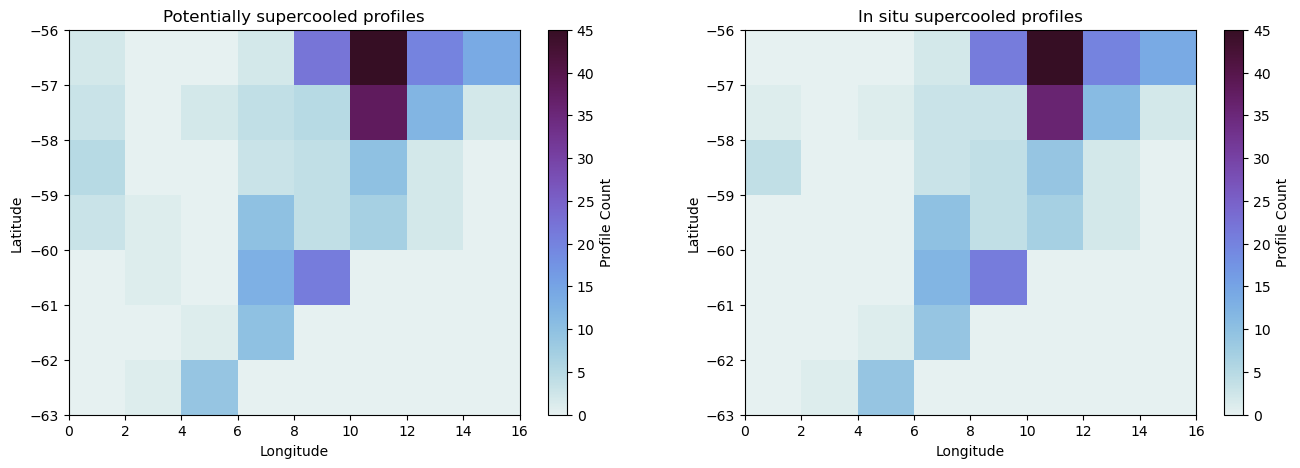

In [239]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sc_types = ['Potentially supercooled', 'In situ supercooled']

for i in range(2):
    if i == 0: # potentially supercooled
        data = data1_filtered
    elif i == 1: # in situ supercooled
        data = data1_filtered_inSC
    
    lat = data['lat']
    lon = data['lon']

    # bins same as in Haumann etl al 2020: 2° lon, 1° lat
    lon_bins = np.arange(lon_min, lon_max+2, 2)
    lat_bins = np.arange(lat_min, lat_max+1, 1)

    # make historgram
    hist = ax[i].hist2d(lon, lat, cmap=cmo.dense, bins=[lon_bins, lat_bins])
    
    # labels
    ax[i].set_xlabel('Longitude')
    ax[i].set_ylabel('Latitude')
    ax[i].set_title(sc_types[i]+" profiles")

    # add colorbar
    cbar = plt.colorbar(hist[3], ax=ax[i])
    cbar.set_label('Profile Count')

### Temporal Distribution

In [240]:
# YEARS

# potentially supercooled profiles#
print("Potentially supercooled profiles by year:")

dates_filtered = pd.Series(data1_filtered["datetimes"])
years, count = np.unique(dates_filtered.dt.year, return_counts=True)
for i in range(len(years)):
    print(years[i],": ",count[i]," profiles", sep = "")

print ("\nIn situ supercooled profiles by year:")
dates_filtered = pd.Series(data1_filtered_inSC["datetimes"])
years, count = np.unique(dates_filtered.dt.year, return_counts=True)
for i in range(len(years)):
    print(years[i],": ",count[i]," profiles", sep = "")


Potentially supercooled profiles by year:
2008: 277 profiles
2015: 1 profiles

In situ supercooled profiles by year:
2008: 257 profiles


=> Nearly all sea ice supercooled profiles in this region are from 2008 (or is it 2009? need to make sure about year of day zero)

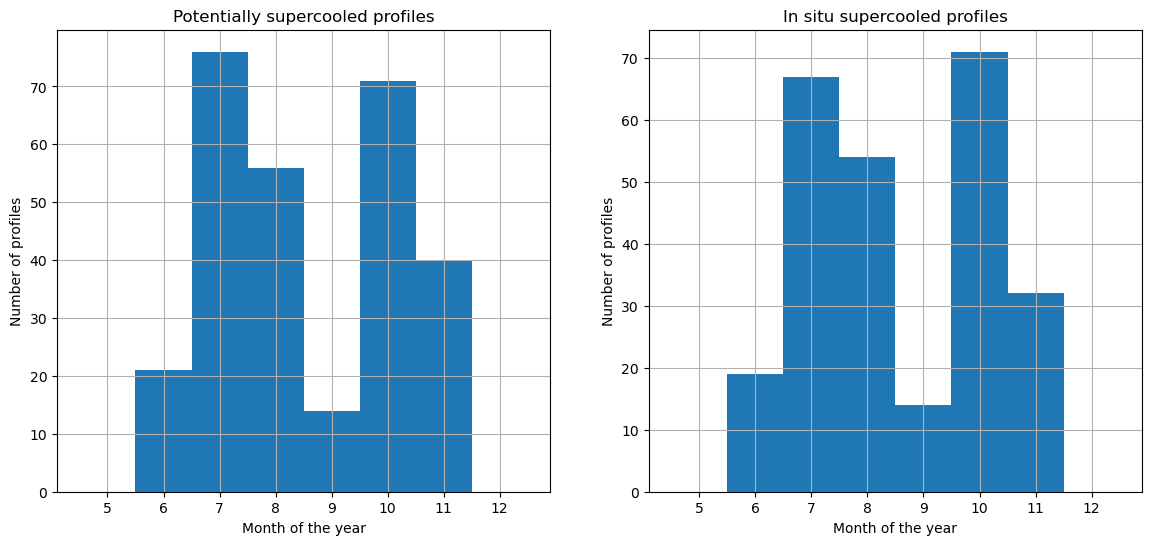

In [ ]:
## MONTHS
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sc_types = ['Potentially supercooled', 'In situ supercooled']

for i in range(2):
    if i == 0: # potentially supercooled
        data = data1_filtered
    elif i == 1: # in situ supercooled
        data = data1_filtered_inSC
    
    dates_filtered = pd.Series(data["datetimes"])
    dates_filtered.dt.month.hist(ax = ax[i], bins=np.arange(5,14)-0.5) # histogram of months, with bins centered on the integers

    # labels
    ax[i].set_xlabel('Month of the year')
    ax[i].set_ylabel('Number of profiles')
    ax[i].set_title(sc_types[i]+" profiles")

=> supercooling occured between June and November

### Spatio-Temporal Distribution

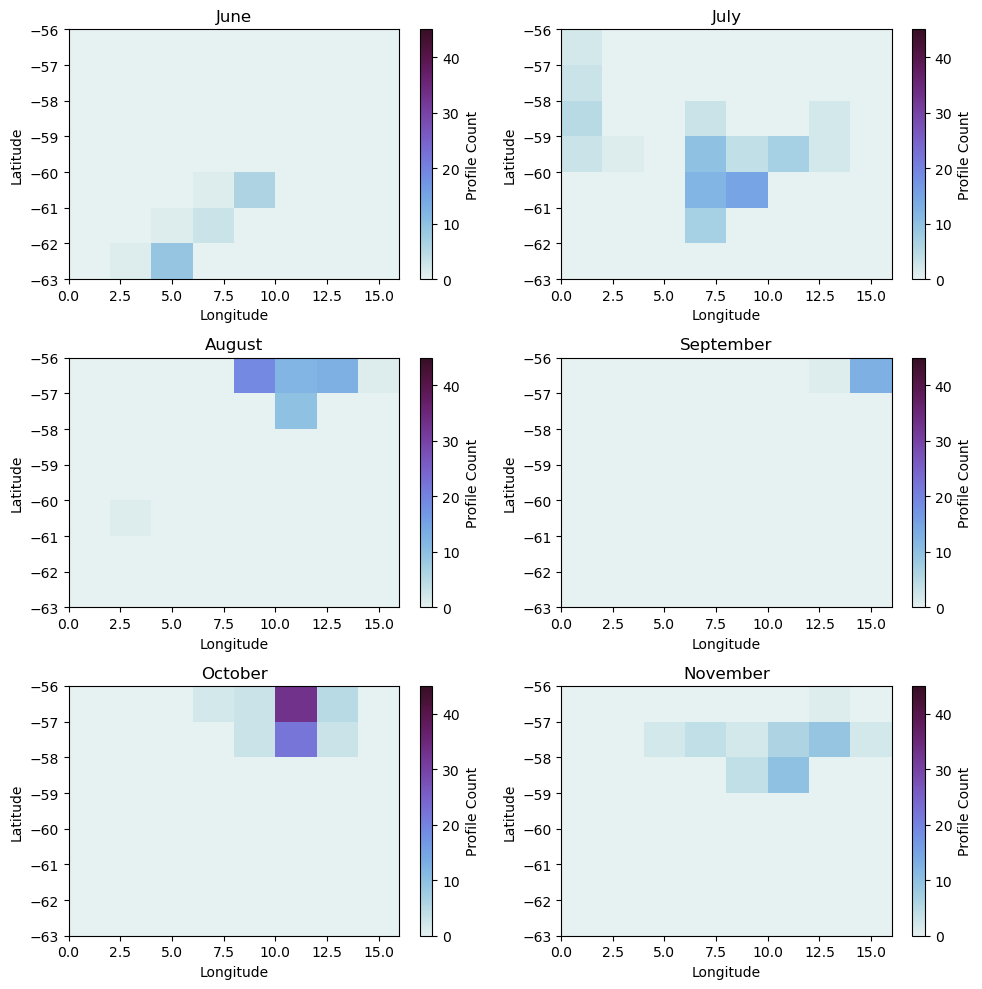

In [274]:
# spatial histogram for each mongth between June and November
months = ["June", "July", "August", "September", "October", "November"]

fig, ax = plt.subplots(3,2, figsize=(10, 10))

for i in range(len(months)):    
    mask_month = [data1_filtered['datetimes'][j].month == i+6 for j in range(len(data1_filtered['id']))] # mask for month i

    data_month = {key: data1_filtered[key][mask_month] for key in data1_filtered.keys()} # filter for month i
    lat = data_month['lat']
    lon = data_month['lon']

    # bins same as in Haumann etl al 2020: 2° lon, 1° lat
    lon_bins = np.arange(lon_min, lon_max+2, 2)
    lat_bins = np.arange(lat_min, lat_max+1, 1)

    # make histogram
    row, col = divmod(i, 2)
    hist = ax[row, col].hist2d(lon, lat, cmap=cmo.dense, bins=[lon_bins, lat_bins], vmin = 0, vmax = 45)
    
    # labels
    ax[row, col].set_xlabel('Longitude')
    ax[row, col].set_ylabel('Latitude')
    ax[row, col].set_title(months[i])

    # add colorbar
    cbar = plt.colorbar(hist[3], ax=ax[row, col])
    cbar.set_label('Profile Count')

plt.tight_layout()

### Maximum Supercooling

Mean Potenital SC: -0.072 °C
30th percentile: -0.106 °C
60th percentile: -0.048 °C


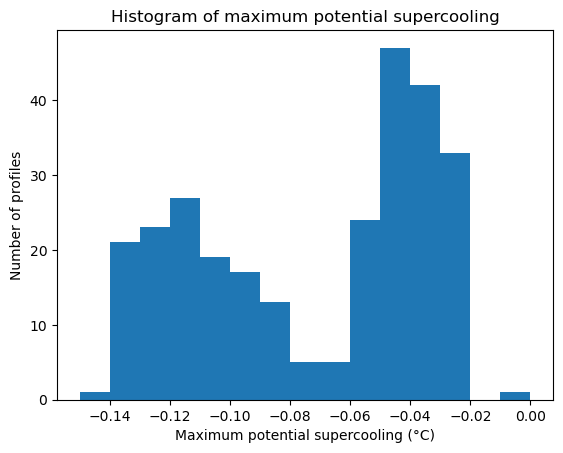

In [509]:
plt.hist(data1_filtered['max_ps'].flatten(), bins = np.arange(-0.15, 0.01, 0.01))
plt.title("Histogram of maximum potential supercooling")
plt.xlabel("Maximum potential supercooling (°C)")
plt.ylabel("Number of profiles")


# mean, median, percentiles
print(f"Mean Potenital SC: {np.mean(data1_filtered['max_ps'].flatten()):.3f} °C")
# print percentiles
print(f"30th percentile: {np.percentile(data1_filtered['max_ps'].flatten(),30):.3f} °C")
print(f"60th percentile: {np.percentile(data1_filtered['max_ps'].flatten(),60):.3f} °C")

### Vertical Extent of Supercooling

Text(0, 0.5, 'Number of profiles')

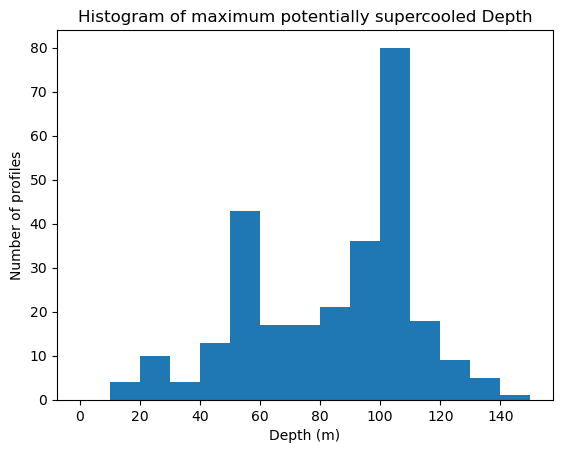

In [489]:
# maximum Depth of pot SC
plt.hist(data1_filtered['bot_ps'].flatten(), bins = np.arange(0, 160, 10))
plt.title("Histogram of maximum potentially supercooled Depth")
plt.xlabel("Depth (m)")
plt.ylabel("Number of profiles")

Text(0, 0.5, 'Number of profiles')

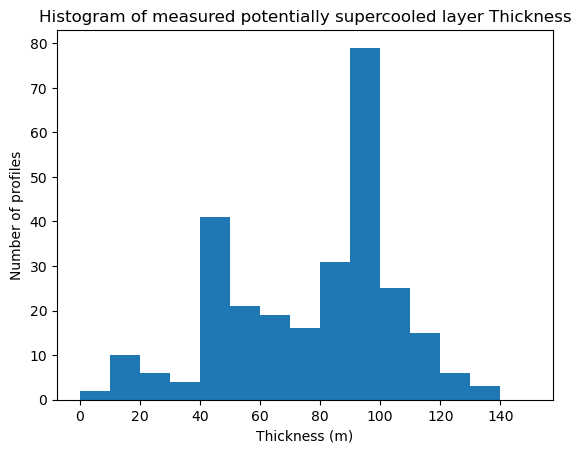

In [490]:
# thickness of pot SC layer
plt.hist(data1_filtered['thickn_ps'].flatten(), bins = np.arange(0, 160, 10))
plt.title("Histogram of measured potentially supercooled layer Thickness")
plt.xlabel("Thickness (m)")
plt.ylabel("Number of profiles")

In [245]:
dist_fromtop = data1_filtered['surf'] - data1_filtered['surf_ps'] # distance from surface to top of potentially supercooled layer
print("Max distance between top of profile and top of pot SC:", max(dist_fromtop))

Max distance between top of profile and top of pot SC: 0.0


### Supercooling Penetration below MLD

Percentage of profiles with potential supercooling penetrating below MLD: 22.3%


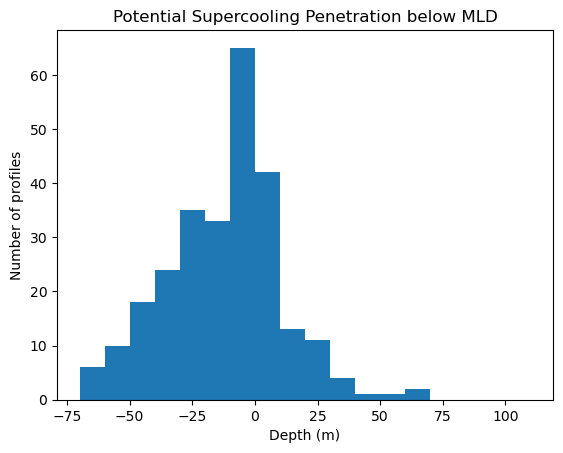

In [246]:
# SC_depth - MLD
dist = data1_filtered['bot_ps']-data1_filtered['mld'] # distance between MLD and bottom of potentially supercooled layer

plt.hist(dist.flatten(), bins = np.arange(-70, 120, 10))
plt.title("Potential Supercooling Penetration below MLD")
plt.xlabel("Depth (m)")
plt.ylabel("Number of profiles")

# percentage of profiles with potential supercooling penetrating below MLD
num_profiles = len(data1_filtered['bot_ps'])
num_penetrating_profiles = np.sum(dist > 0) # count how many profiles have potential supercooling penetrating below MLD
percentage_penetrating = (num_penetrating_profiles / num_profiles) * 100
print(f"Percentage of profiles with potential supercooling penetrating below MLD: {percentage_penetrating:.1f}%")

In [247]:
# SC_depth - pycno_depth
dist = data1_filtered['bot_ps']-data1_filtered['pycno'] # distance between MLD and bottom of potentially supercooled layer
np.nanmax(dist)
print("=> no penetration below pycnocline measured in this region")

=> no penetration below pycnocline measured in this region


### Platform Type and Platform ID

In [248]:
ids, count = np.unique(data1_filtered['id'], return_counts=True) # get unique IDs and their corresponding profile counts

# Print IDs, Counts, and platform types
platform_types = ["ARGO", "ARGO ICE", "MEOP", "CTD"] # 1 = ARGO, 2 = ARGO ICE, 3 = MEOP, 4 = CTD

for i in range(len(ids)):
    mask = data1_filtered['id'] == ids[i] # mask for this ID
    platform_type_num = np.unique(data1_filtered['types'][mask]) # get the unique platform type for this id
    if len(platform_type_num) == 1:
        platform_type = platform_types[int(platform_type_num[0])-1] # get name of platform type
    else:
        print("Warning: multiple platform types found for id ", ids[i], ": ", platform_type_num)

    print(platform_type, ", ID ", int(ids[i]),": ",count[i]," profiles", sep ="")

ARGO ICE, ID 5904467: 1 profiles
MEOP, ID 9900059: 16 profiles
MEOP, ID 9900061: 111 profiles
MEOP, ID 9900109: 150 profiles


=> Nearly all supercooled profiles are from three MEOP sensors

### Profile Selection

We want profiles that have a significant degree of supercooling and should be somewhat representative. So filtering criteria are
- large vertical extent of SC
- max potential supercooling around -0.1°C
- top of profile is close to sea surface -> most profiles are around 5.95 below surface, so this is easy to fullfill
- (profile should be from july/august or october)
- bottom supercooling below or above MLD?

In [516]:
# lets start selecting by vertical extent, as this might result in the other criteria also being fullfilled
print(f"Maximum thickness of supercooled layer: {np.max(data1_filtered_inSC['thickn_ps']):.1f}m")
print(f"Minimum top of profile: {np.min(data1_filtered_inSC['surf']):.2f}m")

# mask_thickn = data1_filtered_inSC['thickn_ps']>100
mask_max_ps = (data1_filtered_inSC['max_ps'] < -0.08) & (data1_filtered_inSC['max_ps']> -0.12)
mask_surf = data1_filtered_inSC['surf']<6
mask_MLD = data1_filtered_inSC['bot_ps'] > data1_filtered_inSC['mld']

mask_final = mask_inSC & mask_surf & mask_max_ps & mask_MLD
data1_preselection = {key: data1_filtered_inSC[key][mask_final] for key in data1_filtered_inSC.keys()}
print("Number of selected profiles:",np.sum(mask_final))

data1_preselection['id']

Maximum thickness of supercooled layer: 134.7m
Minimum top of profile: 5.94m
Number of selected profiles: 23


array([9900109., 9900109., 9900109., 9900109., 9900109., 9900109.,
       9900109., 9900109., 9900109., 9900109., 9900109., 9900109.,
       9900109., 9900109., 9900109., 9900109., 9900109., 9900109.,
       9900109., 9900109., 9900109., 9900109., 9900109.])

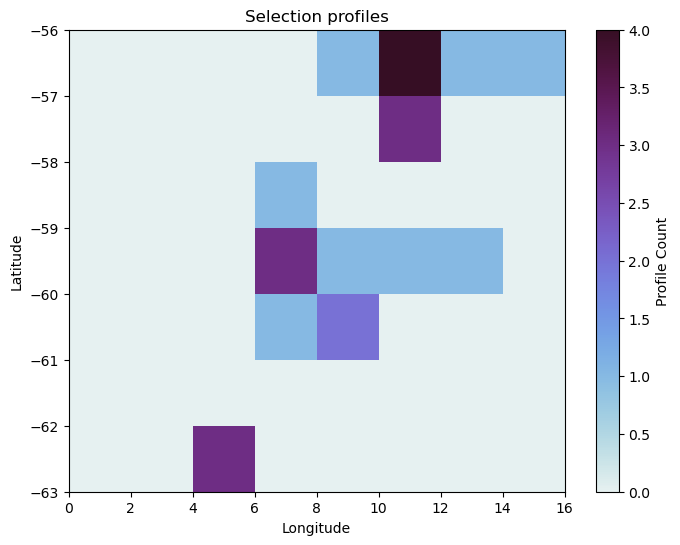

In [402]:
# Where doe the selected profiles lie?

fig, ax = plt.subplots(figsize=(8, 6))

data = data1_preselection

lat = data['lat']
lon = data['lon']

# bins same as in Haumann etl al 2020: 2° lon, 1° lat
lon_bins = np.arange(lon_min, lon_max+2, 2)
lat_bins = np.arange(lat_min, lat_max+1, 1)

# make historgram
hist = ax.hist2d(lon, lat, cmap=cmo.dense, bins=[lon_bins, lat_bins])

# labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title("Selection profiles")

# add colorbar
cbar = plt.colorbar(hist[3], ax=ax)
cbar.set_label('Profile Count')

In [408]:
# select profiles from 56°S to 57°S and 10°E to 12°E
mask_lat = (data1_preselection['lat'] <= -56) & (data1_preselection['lat'] >= -57)
mask_lon = (data1_preselection['lon'] >= 10) & (data1_preselection['lon'] <= 12)
mask_final = mask_lat & mask_lon
data1_selection = {key: data1_preselection[key][mask_final] for key in data1_preselection.keys()}
data1_selection

{'bath': array([5607.5 , 5033.75, 5149.25, 5609.75]),
 'bot': array([562.01988768, 716.10167308, 589.68051173, 528.41962645]),
 'bot_ps': array([124.80646687, 117.87351649, 121.83475565, 139.65893056]),
 'cycle': array([490., 495., 505., 507.]),
 'dates': array([733633.09722222, 733634.81944444, 733639.5625    , 733640.11111111]),
 'dcycle': array([nan, nan, nan, nan]),
 'ddates': array([nan, nan, nan, nan]),
 'f': array([-0.0001221 , -0.00012228, -0.00012224, -0.00012215]),
 'flag': array([0., 0., 0., 0.]),
 'heat_ps': array([-45643584.85384817, -41176599.28552461, -46447556.01938323,
        -48835027.16190901]),
 'id': array([9900109., 9900109., 9900109., 9900109.]),
 'id2': array([14616., 14616., 14616., 14616.]),
 'idx_allps': array([False, False, False, False]),
 'idx_pt0': array([ True,  True,  True,  True]),
 'idx_pt0_noerr': array([ True,  True,  True,  True]),
 'idx_subps': array([False, False, False, False]),
 'idx_t': array([ True,  True,  True,  True]),
 'idx_t_noerr': arr

## Data 1 Other - Non-SC Profiles

I want to look at the other profiles to see how the Seals move, so that we can better judge if the region-shifting of the SC is due to SC processes or simply due to the seal movements.

In [278]:
data1_other = matstructs['data1_other']

### Add datetime variable

In [279]:
# add datetime variable
matlab_zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting
days = data1_other["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts at 1 and includes a leap year in year 0
datetimes = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1_other["datetimes"] = np.array(datetimes)
data1_other.keys()

dict_keys(['cycle', 'dates', 'id', 'id2', 'lat', 'lon', 'types', 'datetimes'])


### Filter for our Region and our MEOP Platforms

We are filtering profiles in our region of interest from the seals that sometimes measured supercooling:

In [294]:
# filter by position and sea ice supercooling
lat_min = -63
lat_max = -56
lon_min = 0
lon_max = 16

mask_lat = (data1_other['lat'] >= lat_min) & (data1_other['lat'] <= lat_max) # latitudes between lat_min and lat_max degrees
mask_lon = (data1_other['lon'] >= lon_min) & (data1_other['lon'] <= lon_max) # longitudes between lon_min and lon_max degrees
mask_seals= np.isin(data1_other['id'], [9900059, 9900061, 9900109])  # sea ice supercooling
mask_final = mask_lat & mask_lon & mask_seals # combine all masks to get the final mask
print("Number of profiles remaining after filtering: ",np.sum(mask_final)) # how many profiles are left after applying the mask?

data1_other_filtered = {key: data1_other[key][mask_final] for key in data1_other.keys()} # filter the data1_other dictionary

Number of profiles remaining after filtering:  536


### Spatio-Temporal Distribution

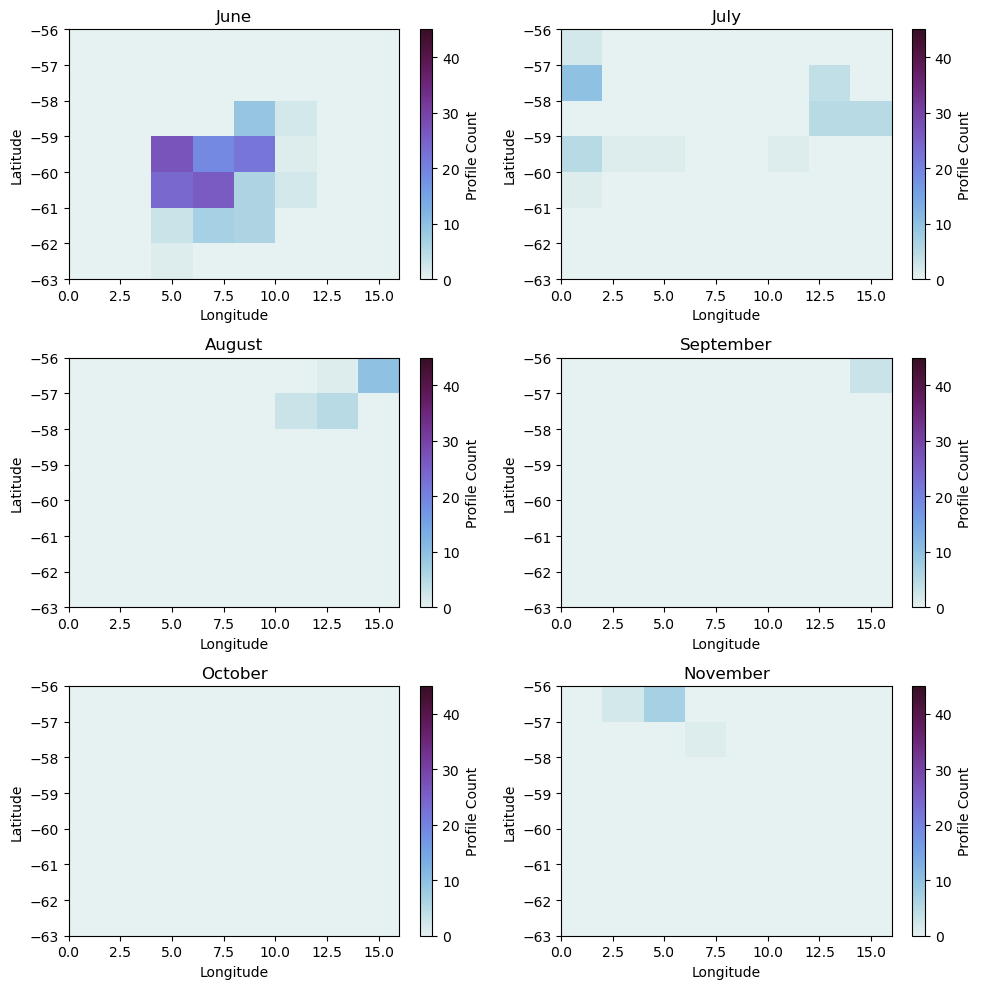

In [295]:
# spatial histogram for each mongth between June and November
months = ["June", "July", "August", "September", "October", "November"]

fig, ax = plt.subplots(3,2, figsize=(10, 10))

for i in range(len(months)):    
    mask_month = [data1_other_filtered['datetimes'][j].month == i+6 for j in range(len(data1_other_filtered['id']))] # mask for month i

    data_month = {key: data1_other_filtered[key][mask_month] for key in data1_other_filtered.keys()} # filter for month i
    lat = data_month['lat']
    lon = data_month['lon']

    # bins same as in Haumann etl al 2020: 2° lon, 1° lat
    lon_bins = np.arange(lon_min, lon_max+2, 2)
    lat_bins = np.arange(lat_min, lat_max+1, 1)

    # make histogram
    row, col = divmod(i, 2)
    hist = ax[row, col].hist2d(lon, lat, cmap=cmo.dense, bins=[lon_bins, lat_bins], vmin = 0, vmax = 45)
    
    # labels
    ax[row, col].set_xlabel('Longitude')
    ax[row, col].set_ylabel('Latitude')
    ax[row, col].set_title(months[i])

    # add colorbar
    cbar = plt.colorbar(hist[3], ax=ax[row, col])
    cbar.set_label('Profile Count')

plt.tight_layout()

## Data 2 - Supercooled Profiles

### Overview

In [466]:
data2_filtered.keys()

dict_keys(['cp', 'def_pt0', 'def_pt0_err', 'def_t', 'def_t_err', 'dpth', 'dpth_mid', 'ds', 'dt', 'gamman', 'n2', 'prs', 'prs_err', 'prs_mid', 'pt0', 'pt0_err', 'rho', 's', 's_err', 'sigma0', 't', 't_err', 't_freeze', 't_freeze0', 't_freeze0_err', 't_freeze_err'])

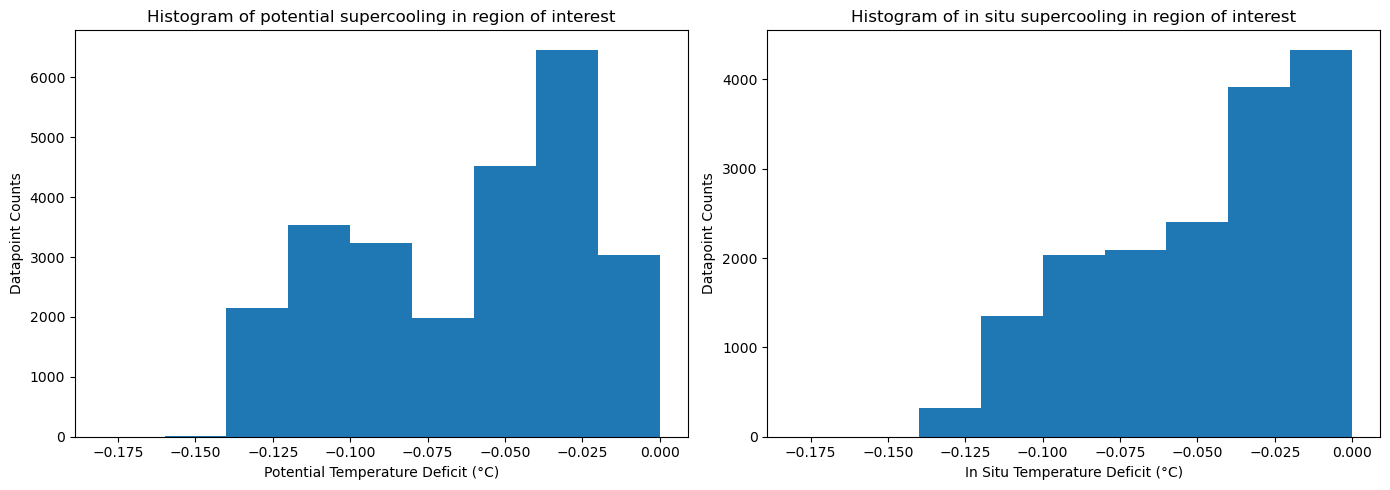

In [526]:
fig, ax = plt.subplots(1,2,figsize = (14,5))

ax[0].hist(data2_filtered["def_pt0"].flatten(), bins = np.arange(-0.18, 0.01, 0.02))

ax[0].set_title("Histogram of potential supercooling in region of interest")
ax[0].set_xlabel("Potential Temperature Deficit (°C)")
ax[0].set_ylabel("Datapoint Counts")

ax[1].hist(data2_filtered['def_t'].flatten(), bins = np.arange(-0.18, 0.01, 0.02))
ax[1].set_title("Histogram of in situ supercooling in region of interest")
ax[1].set_xlabel("In Situ Temperature Deficit (°C)")
ax[1].set_ylabel("Datapoint Counts")

plt.tight_layout()


### Selected Profiles

In [428]:
data2.keys()

dict_keys(['cp', 'def_pt0', 'def_pt0_err', 'def_t', 'def_t_err', 'dpth', 'dpth_mid', 'ds', 'dt', 'gamman', 'n2', 'prs', 'prs_err', 'prs_mid', 'pt0', 'pt0_err', 'rho', 's', 's_err', 'sigma0', 't', 't_err', 't_freeze', 't_freeze0', 't_freeze0_err', 't_freeze_err'])

In [ ]:
# find the indizes of our selected profiles in the original data1 dictionary
mask_dates = np.isin(data1['dates'], data1_selection['dates'])
mask_id = np.isin(data1['id'], data1_selection['id'])

ind_sel = np.where(mask_dates & mask_id)[0]
data2_sel = {key: data2[key][:,ind_sel] for key in data2.keys()}

array([22933, 22938, 22948, 22950])

In [457]:
np.nanmin(data2_sel["def_t"])

np.float64(-0.10676541947277207)

(160.0, 0.0)

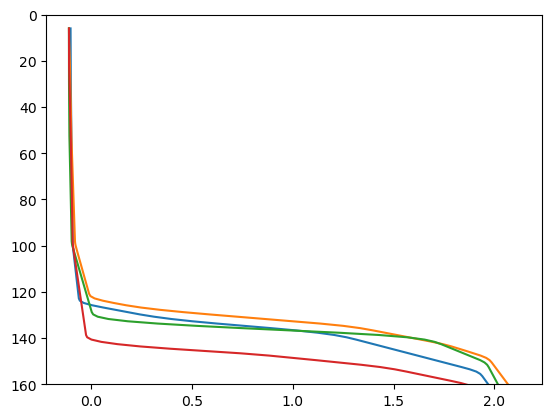

In [ ]:
# Potential Supercooling
for i in range(len(ind_sel)):
    plt.plot(data2_sel['def_pt0'][:,i], data2_sel['dpth'][:,i])
    

(-0.2, 0.1)

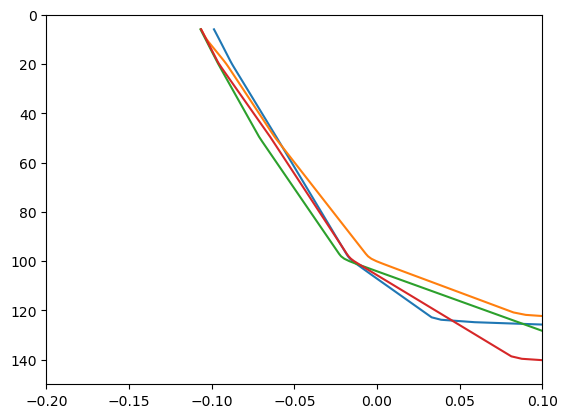

In [461]:
# In situ Supercooling
for i in range(len(ind_sel)):
    plt.plot(data2_sel['def_t'][:,i], data2_sel['dpth'][:,i])
    
plt.ylim(150,0)
plt.xlim(-0.2, 0.1)

### ARGO ICE Profile

In our region of interest, there is one supercooled Argo Profile (id 5904467). Let's have a look at that

In [ ]:
argo_ind = np.where(data1_filtered['id'] == [5904467])
data1_argo = {key: data1_filtered[key][argo_ind][0] for key in data1_filtered.keys()} # filter the data1 dictionary for the ARGO profile


=> The Argo Ice Profile:
- is from 60.4S 3.9E on 2015-08-28 
- has no in-situ supercooling
- goes from 10m depth to 1578m depth
- has potential SC from 10m to 95m
- max potential SC: -0.0036 deg at 18m
- MLD at 123m